In [1]:
import requests
import rioxarray
import pyproj

from xcube.core.store import new_data_store
from xcube_resampling import resample_in_space
from xcube_resampling.gridmapping import GridMapping

In [2]:
import os

S3_USER_STORAGE_KEY = os.environ["S3_USER_STORAGE_KEY"]
S3_USER_STORAGE_SECRET = os.environ["S3_USER_STORAGE_SECRET"]
S3_USER_STORAGE_BUCKET = os.environ["S3_USER_STORAGE_BUCKET"]

irr_store = new_data_store("s3",
                       root=S3_USER_STORAGE_BUCKET,
                       storage_options=dict(anon=False,
                                            key=S3_USER_STORAGE_KEY,
                                            secret=S3_USER_STORAGE_SECRET))

In [3]:
iwu_spatial = irr_store.open_data("iwu_estimates_spatial.zarr")
iwu_temporal = irr_store.open_data("iwu_estimates_temporal.zarr")

In [4]:
# Temporal masking
in_months = [5,6,7,8,9]
iwu_temporal_masked = iwu_temporal.where(iwu_temporal.time.dt.month.isin(in_months), 0)
iwu_spatial_masked = iwu_spatial.where(iwu_spatial.time.dt.month.isin(in_months), 0)

In [16]:
iwu_spatial_masked

<xarray.Dataset> Size: 58GB
Dimensions:      (time: 254, lat: 4144, lon: 6832)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2016-01-01 2016-01-15 ... 2025-09-12
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    iwu_est      (time, lat, lon) float64 58GB dask.array<chunksize=(1, 2072, 1708), meta=np.ndarray>

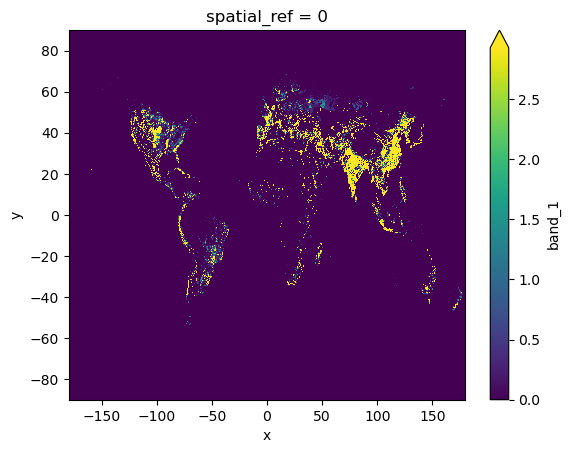

In [8]:
#Spatial masking
fds = new_data_store("file", root=".")
ds = fds.open_data('gmia_v5_aei_pct 1.tif')
ds.band_1.plot(robust=True)

In [9]:
ds

<xarray.Dataset> Size: 37MB
Dimensions:      (x: 4320, y: 2160)
Coordinates:
  * x            (x) float64 35kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
  * y            (y) float64 17kB 89.96 89.88 89.79 ... -89.79 -89.87 -89.96
    spatial_ref  int64 8B 0
Data variables:
    band_1       (y, x) float32 37MB dask.array<chunksize=(512, 512), meta=np.ndarray>
Attributes:
    source:   file:///home/b-yogesh/team-extra/ForYogesh/gmia_v5_aei_pct 1.tif

In [10]:
%%time
bbox = [-12, 34, 51, 73] # Europe (slightly larger to avoid NaNs when resampling)
ds_subset = ds.sel(y=slice(bbox[3], bbox[1]), x=slice(bbox[0], bbox[2]))
ds_subset = ds_subset.rename({'x': 'lon', 'y': 'lat'})
ds_subset

CPU times: user 3.46 ms, sys: 0 ns, total: 3.46 ms
Wall time: 2.89 ms


<xarray.Dataset> Size: 1MB
Dimensions:      (lon: 756, lat: 468)
Coordinates:
  * lon          (lon) float64 6kB -11.96 -11.88 -11.79 ... 50.79 50.87 50.96
  * lat          (lat) float64 4kB 72.96 72.88 72.79 72.71 ... 34.21 34.12 34.04
    spatial_ref  int64 8B 0
Data variables:
    band_1       (lat, lon) float32 1MB dask.array<chunksize=(308, 32), meta=np.ndarray>
Attributes:
    source:   file:///home/b-yogesh/team-extra/ForYogesh/gmia_v5_aei_pct 1.tif

In [12]:
gm_is = GridMapping.from_dataset(iwu_spatial)
gm_is

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-11, 35, 50, 72)
* ij_bbox: (0, 0, 6832, 4144)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (6832, 4144)
* tile_size: (1708, 2072)

In [14]:
gm_it = GridMapping.from_dataset(iwu_temporal)
gm_it

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-11, 35, 50, 72)
* ij_bbox: (0, 0, 6832, 4144)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (6832, 4144)
* tile_size: (50, 50)

In [18]:
# interp method -> nearest neighbor vs bilinear ? we go ahead with bilinear.
ds_in_gm_is = resample_in_space(ds_subset, target_gm = gm_is)
ds_in_gm_is = ds_in_gm_is.rename({"band_1": "mask"})
ds_in_gm_is

<xarray.Dataset> Size: 113MB
Dimensions:      (lat: 4144, lon: 6832)
Coordinates:
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    mask         (lat, lon) float32 113MB dask.array<chunksize=(2072, 1708), meta=np.ndarray>
Attributes:
    source:   file:///home/b-yogesh/team-extra/ForYogesh/gmia_v5_aei_pct 1.tif

In [19]:
# interp method -> nearest neighbor vs bilinear ? we go ahead with bilinear.
ds_in_gm_it = resample_in_space(ds_subset, target_gm = gm_it)
ds_in_gm_it = ds_in_gm_it.rename({"band_1": "mask"})
ds_in_gm_it

<xarray.Dataset> Size: 113MB
Dimensions:      (lat: 4144, lon: 6832)
Coordinates:
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B 0
Data variables:
    mask         (lat, lon) float32 113MB dask.array<chunksize=(50, 50), meta=np.ndarray>
Attributes:
    source:   file:///home/b-yogesh/team-extra/ForYogesh/gmia_v5_aei_pct 1.tif

In [20]:
ds_val = ds_in_gm_is.mask.values

In [21]:
# upsampled
import numpy as np
np.unique(ds_val)

array([0.0000000e+00, 1.3367227e-11, 2.0611835e-11, ..., 9.9918045e+01,
       9.9932915e+01, 9.9956131e+01], shape=(10082915,), dtype=float32)

In [22]:
# original tif
np.unique(ds.band_1.values)

array([0.000000e+00, 1.599685e-11, 1.600179e-11, ..., 9.999997e+01,
       9.999999e+01, 1.000000e+02], shape=(510432,), dtype=float32)

In [41]:
THRESHOLD = 5

filtered_spatial = iwu_spatial_masked['iwu_est'].where(ds_in_gm_is['mask'] > THRESHOLD).squeeze()
filtered_spatial=filtered_spatial.to_dataset(name="iwu_est")

filtered_temporal = iwu_temporal_masked['iwu_est'].where(ds_in_gm_it['mask'] > THRESHOLD).squeeze()
filtered_temporal=filtered_temporal.to_dataset(name="iwu_est")

In [33]:
iwu_spatial

<xarray.Dataset> Size: 58GB
Dimensions:      (time: 254, lat: 4144, lon: 6832)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2016-01-01 2016-01-15 ... 2025-09-12
  * lat          (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon          (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
    spatial_ref  int64 8B ...
Data variables:
    iwu_est      (time, lat, lon) float64 58GB dask.array<chunksize=(1, 2072, 1708), meta=np.ndarray>

In [34]:
from xcube.webapi.viewer import Viewer
viewer = Viewer()

404 GET /viewer/config/config.json (127.0.0.1): xcube viewer has not been been configured
404 GET /viewer/config/config.json (127.0.0.1) 1.86ms
501 GET /viewer/state?key=sentinel (127.0.0.1) 0.71ms
404 GET /viewer/ext/contributions (127.0.0.1) 0.34ms
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/xcube/webapi/statistics/controllers.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  time = np.array(time_label, dtype=dataset.time.dtype)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/xcube/webapi/statistics/controllers.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  time = np.array(time_label, dtype=dataset.time.dtype)
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/xcube/webapi/statistics/controllers.py:62: UserWarning: no explicit representation of timezones available for np.dateti

In [35]:
viewer.add_dataset(filtered_spatial)

'af958632-93fa-4043-85cd-bc5e63a0971e'

In [36]:
viewer.add_dataset(iwu_spatial)

'56f8e0a5-2b9e-49ea-857d-26d0f5b77def'

In [37]:
viewer.add_dataset(iwu_spatial_masked)

'ee7056a8-c96a-4092-87d2-a98b3863878d'

In [44]:
viewer.add_dataset(ds)

'805bc8ce-0b39-4d69-a6ac-7b477167f986'

In [45]:
viewer.show()

In [39]:
%%time
irr_store.write_data(filtered_spatial, "iwu_postprocessed_spatial.zarr")

CPU times: user 1min 27s, sys: 9.61 s, total: 1min 37s
Wall time: 1min 4s


'iwu_postprocessed_spatial.zarr'

In [43]:
%%time
irr_store.write_data(filtered_temporal, "iwu_postprocessed_temporal.zarr")

CPU times: user 2min 28s, sys: 13.9 s, total: 2min 42s
Wall time: 3min 6s


'iwu_postprocessed_temporal.zarr'